# NMF Topic Model — Ireland

**Corpus:** 586 articles post-cleaning (1,040 raw → cleaned by removing gov.ie PDF landing pages, ESRI off-topic content, Teaching Council boilerplate, and articles <200 chars)

**Sources:** gov.ie (57%), ESRI, Teaching Council, Education Research Centre, Education Matters

**Model:** NMF, k=15 (coherence peaks at k=10 but domain review favours k=15 for interpretability), max_features=2000, min_df=3

**Key findings:**
- 15 interpretable topics; 5 highly coherent single-theme clusters, 3 genuine multi-source conversations
- 9/15 topics >85% gov.ie — source composition shapes the topic space, not just topic proportions
- Counterfactual model (non-gov.ie only) reveals 3 framings invisible in the main model: care/disability, economic disadvantage, migration
- Three major Irish policy themes (DEIS, Irish language, teacher supply) absent — explained by source selection, not model failure
- Topic stability: 0.98 across 5 random seeds


In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO)
logging.getLogger("gensim").setLevel(logging.WARNING)

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

from model_pipeline.training.s02_cleaning import run_cleaning
from model_pipeline.training.s03_spacy_processing import run_spacy_processing
from model_pipeline.training.s04_vectorisation import run_vectorisation
from model_pipeline.training.s05_nmf_training import run_nmf_training, get_top_words_per_topic
from model_pipeline.training.s06_topic_allocation import TOPIC_NAMES
from model_pipeline.training.s04_vectorisation import run_vectorisation, build_vectorizer



INFO:model_pipeline.training.s06_topic_allocation:Loaded 30 topic names from llm_topic_review.json


## 1. Load Ireland data only

In [2]:
df_irl = pd.read_csv("../../data/training/irl_training.csv")
df_irl["country"] = "irl"
df_irl["text"] = df_irl["title"].fillna("") + "\n\n" + df_irl["text"].fillna("")
df_irl["date"] = pd.to_datetime(df_irl["article_date"], errors="coerce")

print(f"Ireland corpus: {len(df_irl)} articles")
print(f"By source:\n{df_irl['source'].value_counts()}")

Ireland corpus: 1040 articles
By source:
source
gov_ie               799
esri                 134
teaching_council      40
erc                   34
education_matters     33
Name: count, dtype: int64


## 2. Preprocessing

In [3]:
df_irl = run_cleaning(df_irl)
df_irl = run_spacy_processing(df_irl)
print(f"After preprocessing: {df_irl.shape}")
print(f"Empty text_final: {(df_irl['text_final'].str.len() == 0).sum()}")

INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): starting. Input shape=(1040, 14)
INFO:model_pipeline.training.s02_cleaning:Dropping 26 off-topic ESRI articles (newsletters, economics)
INFO:model_pipeline.training.s02_cleaning:Dropping 428 articles with fewer than 200 chars after cleaning
INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): complete. Output shape=(586, 15)
INFO:model_pipeline.training.s02_cleaning:Empty cleaned texts: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): starting. Input shape=(586, 15)
INFO:model_pipeline.training.s03_spacy_processing:Loading spaCy model: en_core_web_sm
INFO:model_pipeline.training.s03_spacy_processing:spaCy processing complete (tokens_after_spacy created).
INFO:model_pipeline.training.s03_spacy_processing:Post-spaCy junk filtering complete (tokens_final + text_final created).
INFO:model_pipeline.training.s03_spacy_processing:Empty text_final rows: 0
INFO:model_pipeline.training.s03_spacy_processing

After preprocessing: (586, 18)
Empty text_final: 0


## 3. Vectorise + train NMF
k=15, min_df=3, max_df=0.85, max_features=2000, ngram_range=(1,2)

**Note:** 586 articles post-cleaning with k=15 gives ~59 articles per topic. max_features reduced from 3000 to 2000 — smaller corpus supports fewer features, and reconstruction error is slightly better at 2000 (21.59 vs 21.76).


In [4]:
vec_out = run_vectorisation(df_irl, vectorizer=build_vectorizer(min_df=3, max_df=0.85, max_features=2000))

nmf_out = run_nmf_training(vec_out.X, n_topics=15, random_state=42, init="nndsvd", max_iter=1000)

print(f"TF-IDF matrix: {vec_out.X.shape}")
print(f"Vocabulary size: {len(vec_out.feature_names)}")
print(f"Reconstruction error: {nmf_out.reconstruction_error:.4f}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(586, 18)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (586, 2000)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=3 max_df=0.85 max_features=2000 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['ability', 'able', 'absence', 'abuse', 'academic', 'acceptable', 'access', 'access work', 'accessible', 'accommodation', 'accordance', 'account', 'accountability', 'accredited', 'accredited grade', 'accurate', 'achievement', 'act', 'action', 'action plan']
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(586, 2000)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(586, 15) | H shape=(15, 2000)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 21.044093


TF-IDF matrix: (586, 2000)
Vocabulary size: 2000
Reconstruction error: 21.0441


## 3b. Coherence sweep — find optimal k
Ireland has 1,036 articles. k=30 may work but test k=5 to k=30.

INFO:model_pipeline.training.s07_evaluation:Coherence sweep: topic_range=[5, 10, 15, 20, 25, 30]
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=5
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=10
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=15
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=20
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=25
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=30


 n_topics  coherence_cv
        5      0.591599
       10      0.609516
       15      0.602578
       20      0.587820
       25      0.565993
       30      0.565812


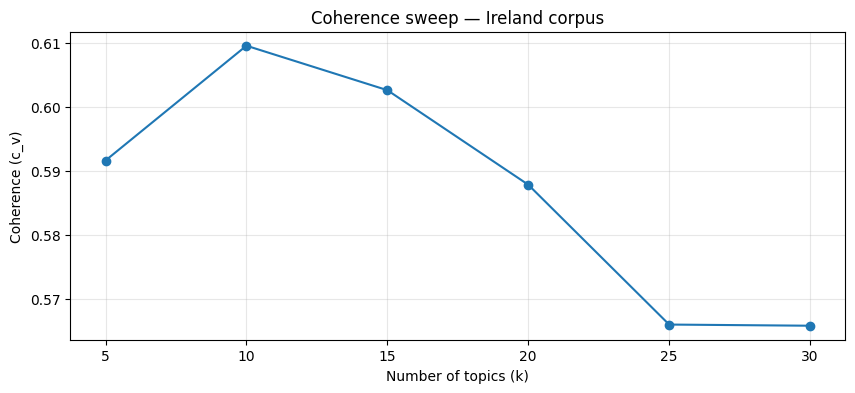


Best k: 10
Choose k based on coherence + interpretability. Update cell 3 if changing from k=30.


In [5]:
from model_pipeline.training.s07_evaluation import evaluate_coherence_over_topic_range
import matplotlib.pyplot as plt

texts_tokens = df_irl["tokens_final"].tolist()

df_coh = evaluate_coherence_over_topic_range(
    X=vec_out.X,
    feature_names=vec_out.feature_names,
    texts_tokens=texts_tokens,
    topic_range=range(5, 35, 5),
    n_top_words=10,
    random_state=42,
    init="nndsvd",
    max_iter=1000,
)

print(df_coh.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(df_coh["n_topics"], df_coh["coherence_cv"], marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence sweep — Ireland corpus")
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(range(5, 35, 5))[df_coh['coherence_cv'].argmax()]
print(f"\nBest k: {best_k}")
print("Choose k based on coherence + interpretability. Update cell 3 if changing from k=30.")


#### Ireland k=15 chosen over k=10. Coherence peaks at k=10 (0.609) on 586 cleaned articles, but domain review shows k=10 produces 3 broad catch-all topics blending distinct policy themes. At k=15 (coherence 0.590), these split into interpretable themes — SEN provision, student wellbeing, school infrastructure, and curriculum emerge as distinct topics while the 6 clean topics from k=10 survive intact. Coherence alone would select k=10; domain-informed review favours k=15.

## 3c. Topic stability across random seeds

In [6]:
seeds = [42, 123, 456, 789, 1024]
H_matrices = []

for seed in seeds:
    model = NMF(n_components=nmf_out.nmf_model.n_components, init="nndsvda", random_state=seed, max_iter=1000)
    model.fit(vec_out.X)
    H_matrices.append(model.components_)
    print(f"Seed {seed}: recon error = {model.reconstruction_err_:.4f}")

pair_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        sim = cosine_similarity(H_matrices[i], H_matrices[j])
        best_matches = sim.max(axis=1).mean()
        pair_scores.append(best_matches)
        print(f"Seeds {seeds[i]} vs {seeds[j]}: avg best-match = {best_matches:.4f}")

avg_stability = np.mean(pair_scores)
print(f"\nOverall topic stability: {avg_stability:.4f}")
print("Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable")


Seed 42: recon error = 21.0441
Seed 123: recon error = 21.0441
Seed 456: recon error = 21.0649
Seed 789: recon error = 21.0441
Seed 1024: recon error = 21.0441
Seeds 42 vs 123: avg best-match = 1.0000
Seeds 42 vs 456: avg best-match = 0.9568
Seeds 42 vs 789: avg best-match = 1.0000
Seeds 42 vs 1024: avg best-match = 1.0000
Seeds 123 vs 456: avg best-match = 0.9568
Seeds 123 vs 789: avg best-match = 1.0000
Seeds 123 vs 1024: avg best-match = 1.0000
Seeds 456 vs 789: avg best-match = 0.9447
Seeds 456 vs 1024: avg best-match = 0.9447
Seeds 789 vs 1024: avg best-match = 1.0000

Overall topic stability: 0.9803
Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable


## 4. Raw topic words

In [7]:
topics_irl = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=20)

print(f"{'Topic':>5}  Top 20 Words")
print("=" * 100)
for i, words in enumerate(topics_irl):
    print(f"{i:>5}  {', '.join(words)}")

Topic  Top 20 Words
    0  school, primary, primary school, post primary, post, design, equipment, furniture, primary primary, building, education, school education, school building, room, support, list, layout, procedure, teacher, team
    1  grade, certificate, mark, subject, process, examination, candidate, guide, student, appeal, accredited grade, accredited, result, school, sec, calculated, calculated grade, sec grade, standardisation, subject school
    2  teaching, council, teaching council, teacher, registration, profession, féilte, register, regulation, professional, council presence, presence platform, teaching profession, presence, platform, bursary, closing teaching, closing, standard, teacher education
    3  young, young people, people, child young, child, support, school, disability, adult, report, inspectorate, participation, activity, finding, care, inspection, need, people school, learning, digital
    4  inspection, early, child, setting, early education, learning, i

## 5a. Filtered top 30 words

In [8]:
display_stop = {
    "school", "education", "pupil", "student", "teacher", "year", "new", "work",
    "time", "say", "make", "good", "need", "use", "know", "want", "come", "take",
    "people", "government", "report", "system", "support", "include", "provide",
    "number", "change", "part", "set", "high", "low", "level", "national", "local",
    "public", "service", "also", "would", "could", "one", "two", "first", "last",
    "week", "month", "day", "told", "said", "according", "cent", "per", "per cent",
    "child", "children", "young", "staff", "area", "programme", "policy",
    "guidance", "framework", "response", "statement", "proposal", "approach",
    "review", "update", "document", "detail", "section", "datum", "figure",
    "survey", "rate", "score", "point", "proportion", "percentage",
    "organisation", "department", "committee", "institute", "foundation",
    "summit", "voice", "stakeholder", "partnership", "engagement",
    "scheme", "initiative", "pilot", "introduce", "implement", "launch",
    "office", "official", "notification", "recipient", "correspondence",
    "cookie", "banner", "subscribe", "contact", "submit", "accessibility",
    "share", "print", "visit", "site", "experience", "article", "news", "blog",
    "interesting", "fact", "previous", "current", "date", "information",
    "different", "large", "place", "individual", "view", "analysis",
    "thing", "way", "job"
}

topics_full = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=100)

print(f"{'Topic':>5}  Top 30 Words (display stopwords removed)")
print("=" * 140)
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    print(f"{i:>5}  {', '.join(filtered)}")

Topic  Top 30 Words (display stopwords removed)
    0  primary, primary school, post primary, post, design, equipment, furniture, primary primary, building, school education, school building, room, list, layout, procedure, team, primary special, webinar, school authority, authority, covid, procedure primary, available school, learning, special school, campaign, furniture equipment, subject, mainstream, anti
    1  grade, certificate, mark, subject, process, examination, candidate, guide, appeal, accredited grade, accredited, result, sec, calculated, calculated grade, sec grade, standardisation, subject school, grade certificate, examination grade, grade process, possible, national standardisation, grade student, school learner, principal, guide state, performance, certificate student, portal
    2  teaching, council, teaching council, registration, profession, féilte, register, regulation, professional, council presence, presence platform, teaching profession, presence, platform, bursa

In [27]:
def explore_topic(topic_id, n=5):
    """Show top N articles for a given topic, ranked by topic weight."""
    W = nmf_out.W
    topic_weights = W[:, topic_id]
    top_idx = topic_weights.argsort()[::-1][:n]

    # Topic words
    words = topics_full[topic_id]
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:20]
    print(f"TOPIC {topic_id} — top words: {', '.join(filtered)}")
    print(f"{'='*120}\n")

    for rank, idx in enumerate(top_idx, 1):
        row = df_irl.iloc[idx]
        weight = topic_weights[idx]
        title = row.get("title", "No title")
        source = row.get("source", "Unknown")
        date = str(row.get("article_date", ""))[:10]
        text = row.get("text_clean", row.get("text", ""))
        if isinstance(text, str) and len(text) > 500:
            text = text[:500] + "..."

        print(f"[{rank}] weight={weight:.4f} | {source} | {date}")
        print(f"    {title}")
        print(f"    {text}\n")

explore_topic(14, n=10)  # topic n, top n articles

TOPIC 14 — top words: special, ncse, class, special educational, special class, educational need, educational, parent, special school, special education, guardian, parent guardian, class special, provision, school place, person, child young, eircode, parent school, planning

[1] weight=0.5495 | gov_ie | 2025-11-04
    National Council for Special Education (NCSE)
    national council for special education the national council for special education was set up to improve the delivery of education services to persons with special educational needs with particular emphasis on children the ncse local service is delivered through their national network of special educational needs organisers who interact with parents and schools the number of senos has increased from to with the aim of providing an improved level of service for parents and schools as part of the f...

[2] weight=0.5451 | gov_ie | 2025-11-20
    What happens now?
    what happens now if you have recently moved address or chan

# 5b. How organisations (government) shape topics 

In [18]:
# Source breakdown for all topics — top 50 articles each
for t in range(nmf_out.nmf_model.n_components):
    top_idx = nmf_out.W[:, t].argsort()[::-1][:50]
    breakdown = df_irl.iloc[top_idx]['source'].value_counts()
    pct = (breakdown / breakdown.sum() * 100).round(0).astype(int)
    summary = ", ".join(f"{src} {p}%" for src, p in pct.items())
    print(f"Topic {t:>2}: {summary}")

Topic  0: gov_ie 98%, erc 2%
Topic  1: gov_ie 100%
Topic  2: teaching_council 80%, gov_ie 12%, education_matters 4%, esri 4%
Topic  3: gov_ie 62%, esri 34%, education_matters 4%
Topic  4: gov_ie 96%, esri 4%
Topic  5: gov_ie 88%, erc 10%, esri 2%
Topic  6: gov_ie 88%, esri 8%, teaching_council 4%
Topic  7: gov_ie 44%, erc 36%, esri 20%
Topic  8: gov_ie 52%, esri 20%, education_matters 14%, erc 8%, teaching_council 6%
Topic  9: gov_ie 90%, esri 10%
Topic 10: gov_ie 94%, erc 4%, teaching_council 2%
Topic 11: gov_ie 94%, esri 4%, education_matters 2%
Topic 12: gov_ie 58%, esri 22%, education_matters 16%, erc 4%
Topic 13: esri 96%, education_matters 2%, gov_ie 2%
Topic 14: gov_ie 92%, esri 6%, erc 2%


In [29]:
# Quick test: what topics emerge without gov_ie?
non_gov = df_irl[df_irl['source'] != 'gov_ie'].copy()
vec_ng = run_vectorisation(non_gov, vectorizer=build_vectorizer(min_df=2, max_features=1500))
nmf_ng = train_nmf(vec_ng.X, n_topics=5, random_state=42, init="nndsvd", max_iter=1000)

topics_ng = get_top_words_per_topic(nmf_ng.nmf_model, vec_ng.feature_names, n_top_words=100)
print("Topics WITHOUT gov_ie:")
print("=" * 120)
for i, words in enumerate(topics_ng):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:20]
    print(f"  {i}: {', '.join(filtered)}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(210, 20)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (210, 1500)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=2 max_df=0.85 max_features=1500 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['ability', 'able', 'absence', 'academic', 'academic performance', 'academic self', 'academic vocation', 'access', 'access work', 'accessible', 'accommodation', 'account', 'accurate', 'achievement', 'acquisition', 'action', 'action roadmap', 'active', 'activity', 'actual']
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(210, 1500)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(210, 5) | H shape=(5, 1500)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 13.225257


Topics WITHOUT gov_ie:
  0: teaching, council, teaching council, registration, profession, féilte, register, professional, regulation, bursary, teaching profession, council presence, presence platform, presence, platform, closing, closing teaching, standard, process, application
  1: young people, care, adult, disability, pathway, young adult, child young, transition, research, old, carer, digital, disabled, scp, study, behaviour, political, activity, health, age
  2: timss, mathematic, primary, science, digital, study, primary school, reading, achievement, skill, educational, assessment, mathematic science, secondary, context, trend, class, attitude, language, practice
  3: migrant, poverty, northern, housing, integration, research, social, income, employment, migration, origin, labour, island, market, deprivation, labour market, social inclusion, inclusion, migrant origin, youth
  4: dublin, social, research, care, use distribution, institute sir, unrestricted use, attribution intern

#### 
At k=15, nine of fifteen Ireland topics are dominated by gov.ie at 85% or above, reflecting the government's 57% share of the corpus. Two topics are dominated by non-government sources — Teaching Council (80%) and ESRI (96%). The remaining four topics show genuinely multi-source composition: international assessment draws from ERC, gov.ie, and ESRI roughly equally; one topic draws from all five sources in the corpus; and curriculum/assessment is a three-way conversation between gov.ie, ESRI, and Education Matters. Compared to k=10, the move to k=15 produced more multi-actor topics (three vs two) and improved the balance of previously single-source topics — ESRI's social research topic shifted from 96% ESRI to a 62/34 gov.ie/ESRI split. Gov.ie still shapes the majority of the topic space, but k=15 gives the non-government voices more room to emerge as distinct contributors rather than being absorbed into government-shaped clusters.

Training a separate model on the 236 non-gov.ie articles reveals three distinct framings that are invisible in the main model: a care/disability/pathways lens, an economic disadvantage framing (poverty, migration, deprivation), and ESRI's cross-border comparative research. Two topics — Teaching Council operations and TIMSS/international assessment — appear in both models, confirming they are robust regardless of corpus composition. A fifth topic turned out to be ESRI's Creative Commons licence footer rather than substantive content. The key finding is that gov.ie's dominance doesn't just affect how much of the topic space it occupies — it determines which ways of framing education policy are discoverable at all. 

## 6. LLM-assisted naming

In [14]:
import os
from pathlib import Path
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re

load_dotenv(Path("../../.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

topic_keyword_lines = []
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    topic_keyword_lines.append(f"Topic {i}: {', '.join(filtered)}")

prompt = f"""You are helping label topics from an NMF topic model trained on Irish education policy documents (2023-2025).
The corpus includes articles from Irish Government (GOV.IE), ESRI, Teaching Council, Education Research Centre, Education Matters, and RTE.

For each topic below, suggest a short descriptive name (2-4 words, snake_case) based on the keywords, and explain in one sentence why you chose it.

{chr(10).join(topic_keyword_lines)}

Return ONLY a JSON list:
[
  {{"topic": 0, "suggested_name": "name", "explanation": "why"}},
  ...
]
No other text, no markdown, no code fences."""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=4096,
    messages=[{"role": "user", "content": prompt}],
)

llm_text = response.content[0].text
cleaned = re.sub(r'^```(?:json)?\n?', '', llm_text.strip())
cleaned = re.sub(r'\n?```$', '', cleaned.strip())
llm_results = json.loads(cleaned)

print(f"{'Topic':>5}  {'LLM Suggestion':<35}  Explanation")
print("=" * 120)
for r in llm_results:
    print(f"{r['topic']:>5}  {r['suggested_name']:<35}  {r['explanation']}")

with open("../../data/evaluation_outputs/llm_ireland_topic_review.json", "w") as f:
    json.dump(llm_results, f, indent=2)

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Topic  LLM Suggestion                       Explanation
    0  school_infrastructure                Keywords focus on physical aspects of schools including buildings, furniture, equipment, design, and room layouts for primary and post-primary schools.
    1  examination_grading                  Keywords center on assessment processes including grades, certificates, marks, examinations, standardization, and appeals procedures.
    2  teacher_registration                 Keywords relate to the Teaching Council's role in professional registration, regulation, standards, and teacher qualification processes.
    3  youth_inclusion                      Keywords emphasize young people, disability, participation, inspectorate activities, and inclusive education pathways for diverse learners.
    4  early_childhood_inspection           Keywords focus on early learning and care settings, inspections, quality evaluation, and early childhood education provision.
    5  school_self_evaluation      

#### 
Ireland k=15 final model: 15 topics, 586 articles. Five strongest topics (state exams, SSE, governance/ethos, international assessment, special education) are highly coherent single-theme clusters. Three topics show genuine multi-source composition (Topics 7, 8, 12). Nine topics are >85% gov.ie — corpus composition, not model flaw. Key gains from k=10: special education (NCSE) emerged as standalone topic, state exams split into grading vs administration, wellbeing separated from SEN. Key absences: no standalone DEIS topic, no Irish language education topic, no teacher supply crisis topic. Labels assigned through manual inspection validated against LLM suggestions.

Three things:
* No DEIS topic — Ireland's central programme for addressing educational disadvantage. Appears as a keyword in Topics 7 and 3 but doesn't form its own theme.
* No Irish language/Gaeltacht education topic — appears at low weight in Topic 8 (policy and strategy) but not standalone
* No teacher supply/workforce crisis topic — prominent in both England and Scotland but absent here. May be framed through Teaching Council registration (Topic 2) rather than as a crisis narrative.
  
Absent topics explained by source selection. Three major Irish education policy themes — DEIS (disadvantage programme), Irish language/Gaeltacht education, and teacher supply crisis — do not emerge as standalone topics. All three have active policy debates but the organisations driving them (teacher unions INTO/TUI/ASTI, specialist bodies like COGG, university researchers at UCD/DCU) are not in the source list. The model correctly reflects the corpus; the corpus reflects source selection choices made before training.


## 7. Finalise Ireland topic names

In [31]:
# Define topic names (k = 15)
IRELAND_TOPIC_NAMES = {
    0: "school_infrastructure_and_design",
    1: "state_examinations",
    2: "teaching_profession_and_regulation",
    3: "student_inclusion_and_participation",
    4: "early_years_and_inspection",
    5: "school_self_evaluation",
    6: "school_governance_and_ethos",
    7: "international_assessment",
    8: "education_policy_and_strategy",
    9: "wellbeing_and_parental_guidance",
    10: "state_examinations_administration",
    11: "staff_employment_and_leave",
    12: "curriculum_and_assessment",
    13: "education_and_social_research",
    14: "special_education"
}

# Check for missing topics (expected range = 15)
expected_topics = range(15)
missing = [i for i in expected_topics if i not in IRELAND_TOPIC_NAMES]

if missing:
    print(f"WARNING: Missing topic names for: {missing}")
else:
    print("All topics named.")

All topics named.


## 8. Topic distribution by source

In [32]:
df_irl["dominant_topic"] = nmf_out.W.argmax(axis=1)
df_irl["dominant_topic_weight"] = nmf_out.W.max(axis=1)

topic_counts = pd.Series(df_irl["dominant_topic"]).value_counts().sort_index()
print("Topic distribution:")
for t, n in topic_counts.items():
    name = IRELAND_TOPIC_NAMES.get(t, f'topic_{t}')
    print(f"  {name}: {n} ({n/len(df_irl)*100:.1f}%)")

print(f"\nDominant weight — mean: {df_irl['dominant_topic_weight'].mean():.4f}")

ct = pd.crosstab(df_irl['source'], df_irl['dominant_topic'], normalize='columns').round(2)
print("\nSource distribution per topic:")
print(ct)

Topic distribution:
  school_infrastructure_and_design: 36 (6.1%)
  state_examinations: 40 (6.8%)
  teaching_profession_and_regulation: 54 (9.2%)
  student_inclusion_and_participation: 34 (5.8%)
  early_years_and_inspection: 36 (6.1%)
  school_self_evaluation: 22 (3.8%)
  school_governance_and_ethos: 13 (2.2%)
  international_assessment: 29 (4.9%)
  education_policy_and_strategy: 76 (13.0%)
  wellbeing_and_parental_guidance: 51 (8.7%)
  state_examinations_administration: 26 (4.4%)
  staff_employment_and_leave: 22 (3.8%)
  curriculum_and_assessment: 56 (9.6%)
  education_and_social_research: 52 (8.9%)
  special_education: 39 (6.7%)

Dominant weight — mean: 0.1983

Source distribution per topic:
dominant_topic      0    1     2     3     4     5     6     7     8     9   \
source                                                                        
education_matters  0.0  0.0  0.06  0.06  0.00  0.00  0.00  0.00  0.16  0.02   
erc                0.0  0.0  0.00  0.03  0.00  0.05  0.00  0

#### Ireland topic distribution: relatively even, no dominant theme. Largest topic is education_policy_and_strategy (13%); five topics cluster at 8-10%. Mean dominant weight 0.198 — articles span multiple topics. Three multi-source topics (7, 8, 12) confirmed as most balanced; curriculum_and_assessment has the most even four-way source split in the model.

## 9. Save model artifacts
**Only run after finalising topic names.**

In [33]:
import joblib
from datetime import datetime

run_id = "irl_" + datetime.now().strftime("%Y-%m-%d_%H%M%S")
run_dir = Path(f"../../experiments/outputs/runs/{run_id}")
run_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(nmf_out.nmf_model, run_dir / "nmf_model.joblib")
joblib.dump(vec_out.vectorizer, run_dir / "vectorizer.joblib")

with open(run_dir / "topic_names.json", "w") as f:
    json.dump(IRELAND_TOPIC_NAMES, f, indent=2)

metadata = {
    "run_id": run_id,
    "country": "ireland",
    "n_articles": len(df_irl),
    "n_topics": nmf_out.nmf_model.n_components,
    "reconstruction_error": float(nmf_out.reconstruction_error),
    "topic_stability": float(avg_stability),
    "corpus": "irl_training",
}
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {run_dir}")
print(f"Contents: {[f.name for f in run_dir.iterdir()]}")


Saved to ../../experiments/outputs/runs/irl_2026-03-22_175356
Contents: ['vectorizer.joblib', 'nmf_model.joblib', 'run_metadata.json', 'topic_names.json']
